# Proyecto Módulo 6 - Aprendizaje de Máquina Supervisado
## Predicción inteligente de gasto en clientes e-commerce
### Lección 1 - Fundamentos del aprendizaje de máquina

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
SEED = 13094978
np.random.seed(SEED)

N_CLIENTES = 1200
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

Path("../data/raw").mkdir(parents=True, exist_ok=True)

# =========================================================
# 1) GENERACIÓN DE VARIABLES BASE
# =========================================================
id_cliente = np.arange(10001, 10001 + N_CLIENTES)

edad = np.random.randint(18, 71, size=N_CLIENTES).astype(float)

sexo = np.random.choice(
    ["Mujer", "Hombre", "Otro"],
    size=N_CLIENTES,
    p=[0.50, 0.47, 0.03]
).astype(object)

ciudad = np.random.choice(
    ["Santiago", "Valparaíso", "Concepción", "La Serena", "Antofagasta", "Temuco", "Rancagua", "Puerto Montt"],
    size=N_CLIENTES
).astype(object)

segmento_cliente = np.random.choice(
    ["Bronce", "Plata", "Oro", "Premium"],
    size=N_CLIENTES,
    p=[0.34, 0.30, 0.22, 0.14]
).astype(object)

canal_adquisicion = np.random.choice(
    ["Orgánico", "Google Ads", "Instagram", "Email", "Referido"],
    size=N_CLIENTES,
    p=[0.24, 0.24, 0.20, 0.16, 0.16]
).astype(object)

cliente_premium = np.random.choice(
    ["Sí", "No"],
    size=N_CLIENTES,
    p=[0.20, 0.80]
).astype(object)

usa_cupon = np.random.choice(
    ["Sí", "No"],
    size=N_CLIENTES,
    p=[0.40, 0.60]
).astype(object)

dispositivo = np.random.choice(
    ["Mobile", "Desktop", "Tablet"],
    size=N_CLIENTES,
    p=[0.58, 0.34, 0.08]
).astype(object)

# =========================================================
# 2) VARIABLES NUMÉRICAS CON LÓGICA DE NEGOCIO
# =========================================================
mapa_segmento = {"Bronce": 0, "Plata": 1, "Oro": 2, "Premium": 3}
segmento_num = pd.Series(segmento_cliente).map(mapa_segmento).values
premium_bin = np.where(cliente_premium == "Sí", 1, 0)
cupon_bin = np.where(usa_cupon == "Sí", 1, 0)
mobile_bin = np.where(dispositivo == "Mobile", 1, 0)

visitas_sitio_mes = np.round(
    np.random.normal(18 + 6 * segmento_num + 7 * premium_bin, 7, N_CLIENTES)
).astype(int)
visitas_sitio_mes = np.clip(visitas_sitio_mes, 1, None)

paginas_vistas = np.round(
    np.random.normal(5 + 0.45 * visitas_sitio_mes + 2 * premium_bin, 6, N_CLIENTES)
).astype(int)
paginas_vistas = np.clip(paginas_vistas, 1, None)

tiempo_promedio_sitio_min = np.round(
    np.random.normal(4 + 0.22 * paginas_vistas + 0.08 * visitas_sitio_mes + 1.4 * premium_bin, 2.8, N_CLIENTES),
    2
)
tiempo_promedio_sitio_min = np.clip(tiempo_promedio_sitio_min, 0.5, None)

compras_previas = np.round(
    np.random.normal(2 + 0.10 * visitas_sitio_mes + 0.12 * tiempo_promedio_sitio_min + 0.9 * premium_bin, 2.2, N_CLIENTES)
).astype(int)
compras_previas = np.clip(compras_previas, 0, None)

dias_desde_ultima_compra = np.round(
    np.random.normal(75 - 4.5 * compras_previas - 5 * segmento_num - 10 * premium_bin, 20, N_CLIENTES)
).astype(int)
dias_desde_ultima_compra = np.clip(dias_desde_ultima_compra, 0, 365)

score_fidelizacion = np.round(
    np.random.normal(48 + 5 * compras_previas + 4 * segmento_num + 8 * premium_bin - 0.12 * dias_desde_ultima_compra, 10, N_CLIENTES)
).astype(float)
score_fidelizacion = np.clip(score_fidelizacion, 1, 100)

carrito_abandonado_pct = np.round(
    np.random.normal(38 - 0.25 * compras_previas - 0.08 * score_fidelizacion + 3 * cupon_bin + 2 * mobile_bin, 10, N_CLIENTES),
    2
)
carrito_abandonado_pct = np.clip(carrito_abandonado_pct, 0, 100)

# =========================================================
# 3) VARIABLE OBJETIVO: MONTO PROMEDIO DE COMPRA
# =========================================================
# Se introduce una relación no completamente lineal para que
# más adelante tenga sentido comparar modelos lineales, KNN y boosting.

monto_promedio_compra = (
    12000
    + 220 * visitas_sitio_mes
    + 180 * paginas_vistas
    + 1150 * compras_previas
    - 85 * dias_desde_ultima_compra
    + 140 * score_fidelizacion
    - 90 * carrito_abandonado_pct
    + 900 * tiempo_promedio_sitio_min
    + 7000 * premium_bin
    + 1800 * segmento_num
    + 1200 * cupon_bin
    + 16 * (visitas_sitio_mes ** 2)   # componente no lineal suave
    + np.random.normal(0, 12000, N_CLIENTES)
)

monto_promedio_compra = np.round(monto_promedio_compra, 2)
monto_promedio_compra = np.clip(monto_promedio_compra, 3000, None)

# =========================================================
# 4) INTRODUCCIÓN INTENCIONAL DE NULOS, INCONSISTENCIAS Y OUTLIERS
# =========================================================
# Nulos
idx_nulos_edad = np.random.choice(N_CLIENTES, size=18, replace=False)
idx_nulos_ciudad = np.random.choice(N_CLIENTES, size=15, replace=False)
idx_nulos_tiempo = np.random.choice(N_CLIENTES, size=14, replace=False)
idx_nulos_score = np.random.choice(N_CLIENTES, size=16, replace=False)

edad[idx_nulos_edad] = np.nan

for i in idx_nulos_ciudad:
    ciudad[i] = None

tiempo_promedio_sitio_min[idx_nulos_tiempo] = np.nan
score_fidelizacion[idx_nulos_score] = np.nan

# Inconsistencias categóricas
idx_segmento_inconsistente = np.random.choice(N_CLIENTES, size=9, replace=False)
segmento_cliente[idx_segmento_inconsistente[:3]] = "premium"
segmento_cliente[idx_segmento_inconsistente[3:6]] = "ORO"
segmento_cliente[idx_segmento_inconsistente[6:]] = "plata "

idx_ciudad_inconsistente = np.random.choice(N_CLIENTES, size=9, replace=False)
ciudad[idx_ciudad_inconsistente[:3]] = "santiago"
ciudad[idx_ciudad_inconsistente[3:6]] = "Valparaíso "
ciudad[idx_ciudad_inconsistente[6:]] = "CONCEPCIÓN"

idx_canal_inconsistente = np.random.choice(N_CLIENTES, size=6, replace=False)
canal_adquisicion[idx_canal_inconsistente[:2]] = "google ads"
canal_adquisicion[idx_canal_inconsistente[2:4]] = "EMAIL "
canal_adquisicion[idx_canal_inconsistente[4:]] = "organico"

idx_dispositivo_inconsistente = np.random.choice(N_CLIENTES, size=6, replace=False)
dispositivo[idx_dispositivo_inconsistente[:2]] = "mobile"
dispositivo[idx_dispositivo_inconsistente[2:4]] = "DESKTOP"
dispositivo[idx_dispositivo_inconsistente[4:]] = "tablet "

# Outliers
idx_outliers = np.random.choice(N_CLIENTES, size=10, replace=False)
visitas_sitio_mes[idx_outliers] = visitas_sitio_mes[idx_outliers] * 3
paginas_vistas[idx_outliers] = paginas_vistas[idx_outliers] * 2
monto_promedio_compra[idx_outliers] = np.round(monto_promedio_compra[idx_outliers] * 3.8, 2)

# =========================================================
# 5) CREACIÓN DEL DATAFRAME
# =========================================================
df_ml = pd.DataFrame({
    "id_cliente": id_cliente,
    "edad": edad,
    "sexo": sexo,
    "ciudad": ciudad,
    "segmento_cliente": segmento_cliente,
    "canal_adquisicion": canal_adquisicion,
    "cliente_premium": cliente_premium,
    "usa_cupon": usa_cupon,
    "dispositivo": dispositivo,
    "visitas_sitio_mes": visitas_sitio_mes,
    "paginas_vistas": paginas_vistas,
    "tiempo_promedio_sitio_min": tiempo_promedio_sitio_min,
    "compras_previas": compras_previas,
    "dias_desde_ultima_compra": dias_desde_ultima_compra,
    "score_fidelizacion": score_fidelizacion,
    "carrito_abandonado_pct": carrito_abandonado_pct,
    "monto_promedio_compra": monto_promedio_compra
})

df_ml.to_csv(RUTA_DATASET_RAW, index=False)

# =========================================================
# 6) INSPECCIÓN INICIAL
# =========================================================
print("===== PRIMERAS 5 FILAS =====")
display(df_ml.head())

print("===== DIMENSIONES =====")
print(df_ml.shape)

print("\n===== TIPOS DE DATOS =====")
display(df_ml.dtypes.to_frame("tipo_dato"))

print("\n===== VALORES FALTANTES =====")
display(df_ml.isna().sum().to_frame("nulos").sort_values(by="nulos", ascending=False))

print("\n===== RESUMEN DEL TARGET =====")
display(df_ml["monto_promedio_compra"].describe().to_frame("monto_promedio_compra"))

print("\n===== VARIABLES CATEGÓRICAS CON POSIBLES INCONSISTENCIAS =====")
for col in ["segmento_cliente", "ciudad", "canal_adquisicion", "dispositivo"]:
    print(f"\nValores únicos en {col}:")
    print(sorted(pd.Series(df_ml[col].dropna().unique()).astype(str).tolist()))

print(f"\nArchivo guardado en: {RUTA_DATASET_RAW}")

===== PRIMERAS 5 FILAS =====


,id_cliente,edad,sexo,ciudad,segmento_cliente,canal_adquisicion,cliente_premium,usa_cupon,dispositivo,visitas_sitio_mes,paginas_vistas,tiempo_promedio_sitio_min,compras_previas,dias_desde_ultima_compra,score_fidelizacion,carrito_abandonado_pct,monto_promedio_compra
0,10001,54.0,Mujer,La Serena,Bronce,Referido,No,Sí,Desktop,29,22,8.93,4,47,73.0,34.22,48320.04
1,10002,66.0,Hombre,Rancagua,Oro,Referido,Sí,Sí,Mobile,33,34,15.52,7,39,97.0,33.62,88514.39
2,10003,24.0,Hombre,Puerto Montt,Plata,Google Ads,Sí,No,Desktop,36,20,14.02,3,32,72.0,47.47,69605.84
3,10004,45.0,Mujer,Concepción,Premium,Orgánico,No,No,Mobile,37,7,9.27,6,27,93.0,26.61,79815.09
4,10005,53.0,Hombre,La Serena,Premium,Orgánico,No,No,Mobile,36,24,16.12,12,8,100.0,28.10,69923.19


===== DIMENSIONES =====
(1200, 17)

===== TIPOS DE DATOS =====


,tipo_dato
id_cliente,int64
edad,float64
sexo,str
ciudad,str
segmento_cliente,str
canal_adquisicion,str
cliente_premium,str
usa_cupon,str
dispositivo,str
visitas_sitio_mes,int64



===== VALORES FALTANTES =====


,nulos
edad,18
score_fidelizacion,16
ciudad,15
tiempo_promedio_sitio_min,14
id_cliente,0
canal_adquisicion,0
cliente_premium,0
sexo,0
segmento_cliente,0
dispositivo,0



===== RESUMEN DEL TARGET =====


,monto_promedio_compra
count,1200.000000
mean,59062.232958
std,29207.236744
min,3000.000000
25%,40683.235000
50%,55806.380000
75%,73319.910000
max,409286.300000



===== VARIABLES CATEGÓRICAS CON POSIBLES INCONSISTENCIAS =====

Valores únicos en segmento_cliente:
['Bronce', 'ORO', 'Oro', 'Plata', 'Premium', 'plata ', 'premium']

Valores únicos en ciudad:
['Antofagasta', 'CONCEPCIÓN', 'Concepción', 'La Serena', 'Puerto Montt', 'Rancagua', 'Santiago', 'Temuco', 'Valparaíso', 'Valparaíso ', 'santiago']

Valores únicos en canal_adquisicion:
['EMAIL ', 'Email', 'Google Ads', 'Instagram', 'Orgánico', 'Referido', 'google ads', 'organico']

Valores únicos en dispositivo:
['DESKTOP', 'Desktop', 'Mobile', 'Tablet', 'mobile', 'tablet ']

Archivo guardado en: ../data/raw/clientes_ecommerce_ml_raw.csv


### Hallazgos de la Lección 1

En esta primera etapa se definió el problema como una tarea de **regresión supervisada**, dado que el objetivo consiste en estimar una variable numérica continua: el monto promedio de compra de un cliente. Asimismo, se identificaron las etapas del pipeline general del proyecto y se generó un dataset base coherente con el contexto de negocio e-commerce.

La base simulada incorpora variables demográficas, de comportamiento en el sitio y de historial comercial, además de valores faltantes, inconsistencias categóricas y outliers controlados. Esto permitirá desarrollar en las siguientes lecciones procesos de validación, preprocesamiento, entrenamiento, comparación y optimización de modelos de aprendizaje supervisado.

## Lección 2 - Nivel de ajuste del modelo y validación cruzada

In [6]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CARGA DEL DATASET
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"
df_modelo = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES DEL DATASET =====")
print(df_modelo.shape)

# =========================================================
# 1) LIMPIEZA MÍNIMA DE TEXTO PARA ESTA ETAPA
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["segmento_cliente", "ciudad", "canal_adquisicion", "dispositivo"]:
    df_modelo[col] = df_modelo[col].apply(normalizar_texto)

df_modelo["segmento_cliente"] = df_modelo["segmento_cliente"].map(mapa_segmento)
df_modelo["ciudad"] = df_modelo["ciudad"].map(mapa_ciudad)
df_modelo["canal_adquisicion"] = df_modelo["canal_adquisicion"].map(mapa_canal)
df_modelo["dispositivo"] = df_modelo["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"

X = df_modelo.drop(columns=["id_cliente", target])
y = df_modelo[target]

# =========================================================
# 3) IDENTIFICAR COLUMNAS NUMÉRICAS Y CATEGÓRICAS
# =========================================================
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("\n===== COLUMNAS NUMÉRICAS =====")
print(columnas_numericas)

print("\n===== COLUMNAS CATEGÓRICAS =====")
print(columnas_categoricas)

# =========================================================
# 4) PREPROCESAMIENTO MÍNIMO
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

# =========================================================
# 5) TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

print("\n===== TAMAÑOS DE ENTRENAMIENTO Y PRUEBA =====")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# =========================================================
# 6) MODELO BASE: REGRESIÓN LINEAL
# =========================================================
modelo_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

modelo_base.fit(X_train, y_train)

pred_train = modelo_base.predict(X_train)
pred_test = modelo_base.predict(X_test)

# =========================================================
# 7) MÉTRICAS TRAIN Y TEST
# =========================================================
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

mae_train, mse_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
mae_test, mse_test, rmse_test, r2_test = calcular_metricas(y_test, pred_test)

resumen_ajuste = pd.DataFrame([
    ["Entrenamiento", mae_train, mse_train, rmse_train, r2_train],
    ["Prueba", mae_test, mse_test, rmse_test, r2_test]
], columns=["conjunto", "MAE", "MSE", "RMSE", "R2"])

print("\n===== MÉTRICAS DE AJUSTE =====")
display(resumen_ajuste.round(4))

# =========================================================
# 8) VALIDACIÓN CRUZADA CON K-FOLDS
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_r2 = cross_val_score(
    modelo_base,
    X,
    y,
    cv=kf,
    scoring="r2"
)

cv_rmse = np.sqrt(
    -cross_val_score(
        modelo_base,
        X,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

resumen_cv = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5],
    "R2": cv_r2,
    "RMSE": cv_rmse
})

print("\n===== VALIDACIÓN CRUZADA (5-FOLDS) =====")
display(resumen_cv.round(4))

print("\nPromedio R2 CV:", round(cv_r2.mean(), 4))
print("Desviación estándar R2 CV:", round(cv_r2.std(), 4))
print("Promedio RMSE CV:", round(cv_rmse.mean(), 4))
print("Desviación estándar RMSE CV:", round(cv_rmse.std(), 4))

# =========================================================
# 9) INTERPRETACIÓN INICIAL DEL AJUSTE
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
if r2_train - r2_test > 0.10:
    print("Existe una diferencia importante entre entrenamiento y prueba, lo que sugiere posible sobreajuste.")
elif r2_train < 0.50 and r2_test < 0.50:
    print("El modelo muestra un ajuste débil tanto en entrenamiento como en prueba, lo que sugiere posible subajuste.")
else:
    print("El modelo muestra un ajuste relativamente consistente entre entrenamiento y prueba.")

print(
    f"R2 entrenamiento: {r2_train:.4f} | R2 prueba: {r2_test:.4f}"
)
print(
    f"RMSE entrenamiento: {rmse_train:.4f} | RMSE prueba: {rmse_test:.4f}"
)

===== DIMENSIONES DEL DATASET =====
(1200, 17)

===== COLUMNAS NUMÉRICAS =====
['edad', 'visitas_sitio_mes', 'paginas_vistas', 'tiempo_promedio_sitio_min', 'compras_previas', 'dias_desde_ultima_compra', 'score_fidelizacion', 'carrito_abandonado_pct']

===== COLUMNAS CATEGÓRICAS =====
['sexo', 'ciudad', 'segmento_cliente', 'canal_adquisicion', 'cliente_premium', 'usa_cupon', 'dispositivo']

===== TAMAÑOS DE ENTRENAMIENTO Y PRUEBA =====
X_train: (960, 15)
X_test: (240, 15)
y_train: (960,)
y_test: (240,)

===== MÉTRICAS DE AJUSTE =====


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25608\221999253.py:83: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()


,conjunto,MAE,MSE,RMSE,R2
0,Entrenamiento,11255.0437,2.400902e+08,15494.8458,0.7385
1,Prueba,11390.1594,1.998997e+08,14138.5877,0.6601



===== VALIDACIÓN CRUZADA (5-FOLDS) =====


,fold,R2,RMSE
0,1,0.6601,14138.5877
1,2,0.7201,14420.3601
2,3,0.6835,15966.4287
3,4,0.7216,17263.6409
4,5,0.7529,16029.7330



Promedio R2 CV: 0.7077
Desviación estándar R2 CV: 0.0324
Promedio RMSE CV: 15563.7501
Desviación estándar RMSE CV: 1149.5519

===== INTERPRETACIÓN INICIAL =====
El modelo muestra un ajuste relativamente consistente entre entrenamiento y prueba.
R2 entrenamiento: 0.7385 | R2 prueba: 0.6601
RMSE entrenamiento: 15494.8458 | RMSE prueba: 14138.5877


### Hallazgos de la Lección 2

En esta etapa se entrenó un modelo base de regresión lineal y se comparó su desempeño entre entrenamiento y prueba, con el fin de identificar señales tempranas de ajuste insuficiente o sobreajuste. Además, se aplicó validación cruzada con K-Folds para obtener una medida más robusta del rendimiento del modelo en distintas particiones de los datos.

Este análisis permitió establecer una primera línea base de desempeño, la cual servirá como referencia para evaluar el efecto del preprocesamiento, la comparación entre modelos y las técnicas de optimización que se aplicarán en las siguientes etapas.

## Lección 3 - Preprocesamiento y escalamiento de datos

In [7]:
import pandas as pd
import numpy as np
import unicodedata
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"
RUTA_DATASET_LIMPIO = "../data/interim/clientes_ecommerce_ml_limpio.csv"
RUTA_OUTLIERS = "../data/interim/resumen_outliers_ml.csv"

Path("../data/interim").mkdir(parents=True, exist_ok=True)

df_prep = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES INICIALES =====")
print(df_prep.shape)

# =========================================================
# 1) NORMALIZACIÓN DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_prep[col] = df_prep[col].apply(normalizar_texto)

df_prep["sexo"] = df_prep["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_prep["ciudad"] = df_prep["ciudad"].map(mapa_ciudad)
df_prep["segmento_cliente"] = df_prep["segmento_cliente"].map(mapa_segmento)
df_prep["canal_adquisicion"] = df_prep["canal_adquisicion"].map(mapa_canal)
df_prep["cliente_premium"] = df_prep["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_prep["usa_cupon"] = df_prep["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_prep["dispositivo"] = df_prep["dispositivo"].map(mapa_dispositivo)

print("\n===== VALORES FALTANTES ANTES DEL TRATAMIENTO =====")
display(df_prep.isna().sum().to_frame("nulos").sort_values(by="nulos", ascending=False))

# =========================================================
# 2) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"
X = df_prep.drop(columns=["id_cliente", target]).copy()
y = df_prep[target].copy()

# Separación train/test antes de calcular límites de outliers
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

# =========================================================
# 3) IDENTIFICAR COLUMNAS NUMÉRICAS Y CATEGÓRICAS
# =========================================================
columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("\n===== COLUMNAS NUMÉRICAS =====")
print(columnas_numericas)

print("\n===== COLUMNAS CATEGÓRICAS =====")
print(columnas_categoricas)

# =========================================================
# 4) TRATAMIENTO DE OUTLIERS (IQR CAPPING SOBRE TRAIN)
# =========================================================
def calcular_limites_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    return li, ls

resumen_outliers = []
limites_outliers = {}

for col in columnas_numericas:
    serie_train = X_train[col].dropna()

    li, ls = calcular_limites_iqr(serie_train)
    limites_outliers[col] = (li, ls)

    outliers_train_antes = ((X_train[col] < li) | (X_train[col] > ls)).sum()
    outliers_test_antes = ((X_test[col] < li) | (X_test[col] > ls)).sum()

    X_train[col] = X_train[col].clip(lower=li, upper=ls)
    X_test[col] = X_test[col].clip(lower=li, upper=ls)

    outliers_train_despues = ((X_train[col] < li) | (X_train[col] > ls)).sum()
    outliers_test_despues = ((X_test[col] < li) | (X_test[col] > ls)).sum()

    resumen_outliers.append({
        "variable": col,
        "limite_inferior": li,
        "limite_superior": ls,
        "outliers_train_antes": int(outliers_train_antes),
        "outliers_train_despues": int(outliers_train_despues),
        "outliers_test_antes": int(outliers_test_antes),
        "outliers_test_despues": int(outliers_test_despues)
    })

df_outliers = pd.DataFrame(resumen_outliers)
df_outliers.to_csv(RUTA_OUTLIERS, index=False)

print("\n===== RESUMEN DE OUTLIERS =====")
display(df_outliers.round(4))

# =========================================================
# 5) PREPROCESAMIENTO FORMAL: IMPUTACIÓN, CODIFICACIÓN, ESCALAMIENTO
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

X_train_preparado = preprocessor.fit_transform(X_train)
X_test_preparado = preprocessor.transform(X_test)

# =========================================================
# 6) DATASET LIMPIO PARA TRAZABILIDAD
# =========================================================
df_limpio = pd.concat([X, y], axis=1)
df_limpio.to_csv(RUTA_DATASET_LIMPIO, index=False)

# =========================================================
# 7) INFORMACIÓN FINAL DE LA ETAPA
# =========================================================
print("\n===== DIMENSIONES TRAS EL PREPROCESAMIENTO =====")
print(f"X_train preparado: {X_train_preparado.shape}")
print(f"X_test preparado: {X_test_preparado.shape}")

print("\n===== VALORES FALTANTES EN EL DATASET LIMPIO (ANTES DE IMPUTACIÓN EN PIPELINE) =====")
display(df_limpio.isna().sum().to_frame("nulos").sort_values(by="nulos", ascending=False))

print("\n===== MUESTRA DE CATEGORÍAS LIMPIAS =====")
for col in columnas_categoricas:
    print(f"\n{col}:")
    print(sorted(pd.Series(df_prep[col].dropna().unique()).astype(str).tolist()))

print(f"\nArchivo dataset limpio guardado en: {RUTA_DATASET_LIMPIO}")
print(f"Archivo resumen de outliers guardado en: {RUTA_OUTLIERS}")

===== DIMENSIONES INICIALES =====
(1200, 17)

===== VALORES FALTANTES ANTES DEL TRATAMIENTO =====


,nulos
edad,18
score_fidelizacion,16
ciudad,15
tiempo_promedio_sitio_min,14
id_cliente,0
canal_adquisicion,0
cliente_premium,0
sexo,0
segmento_cliente,0
dispositivo,0



===== COLUMNAS NUMÉRICAS =====
['edad', 'visitas_sitio_mes', 'paginas_vistas', 'tiempo_promedio_sitio_min', 'compras_previas', 'dias_desde_ultima_compra', 'score_fidelizacion', 'carrito_abandonado_pct']

===== COLUMNAS CATEGÓRICAS =====
['sexo', 'ciudad', 'segmento_cliente', 'canal_adquisicion', 'cliente_premium', 'usa_cupon', 'dispositivo']

===== RESUMEN DE OUTLIERS =====


,variable,limite_inferior,limite_superior,outliers_train_antes,outliers_train_despues,outliers_test_antes,outliers_test_despues
0,edad,-8.0000,96.0000,0,0,0,0
1,visitas_sitio_mes,-0.5000,51.5000,12,0,1,0
2,paginas_vistas,-3.0000,37.0000,6,0,1,0
3,tiempo_promedio_sitio_min,0.5275,19.1475,14,0,1,0
4,compras_previas,-2.0000,14.0000,1,0,0,0
5,dias_desde_ultima_compra,-28.0000,108.0000,2,0,2,0
6,score_fidelizacion,23.0000,135.0000,2,0,1,0
7,carrito_abandonado_pct,3.1325,61.7725,2,0,2,0



===== DIMENSIONES TRAS EL PREPROCESAMIENTO =====
X_train preparado: (960, 35)
X_test preparado: (240, 35)

===== VALORES FALTANTES EN EL DATASET LIMPIO (ANTES DE IMPUTACIÓN EN PIPELINE) =====


,nulos
edad,18
score_fidelizacion,16
ciudad,15
tiempo_promedio_sitio_min,14
canal_adquisicion,0
cliente_premium,0
sexo,0
segmento_cliente,0
dispositivo,0
usa_cupon,0



===== MUESTRA DE CATEGORÍAS LIMPIAS =====

sexo:
['Hombre', 'Mujer', 'Otro']

ciudad:
['Antofagasta', 'Concepción', 'La Serena', 'Puerto Montt', 'Rancagua', 'Santiago', 'Temuco', 'Valparaíso']

segmento_cliente:
['Bronce', 'Oro', 'Plata', 'Premium']

canal_adquisicion:
['Email', 'Google Ads', 'Instagram', 'Orgánico', 'Referido']

cliente_premium:
['No', 'Sí']

usa_cupon:
['No', 'Sí']

dispositivo:
['Desktop', 'Mobile', 'Tablet']

Archivo dataset limpio guardado en: ../data/interim/clientes_ecommerce_ml_limpio.csv
Archivo resumen de outliers guardado en: ../data/interim/resumen_outliers_ml.csv


### Hallazgos de la Lección 3

En esta etapa se realizó el preprocesamiento formal del dataset, incluyendo normalización de texto, corrección de inconsistencias categóricas, tratamiento de outliers mediante capping con criterio IQR, imputación de valores faltantes y transformación de variables categóricas mediante codificación one-hot. Asimismo, las variables numéricas fueron estandarizadas para dejar una representación compatible con algoritmos sensibles a escala.

Con ello, el conjunto de datos quedó preparado para el entrenamiento de modelos supervisados más robustos, reduciendo problemas asociados a formatos erróneos, valores faltantes y diferencias de magnitud entre variables.

## Lección 4 - Regresiones

In [8]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

df_reg = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# 1) LIMPIEZA DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_reg[col] = df_reg[col].apply(normalizar_texto)

df_reg["sexo"] = df_reg["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_reg["ciudad"] = df_reg["ciudad"].map(mapa_ciudad)
df_reg["segmento_cliente"] = df_reg["segmento_cliente"].map(mapa_segmento)
df_reg["canal_adquisicion"] = df_reg["canal_adquisicion"].map(mapa_canal)
df_reg["cliente_premium"] = df_reg["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_reg["usa_cupon"] = df_reg["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_reg["dispositivo"] = df_reg["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"

X = df_reg.drop(columns=["id_cliente", target]).copy()
y = df_reg[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# =========================================================
# 3) PREPROCESADOR BASE
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

# =========================================================
# 4) MODELO LINEAL
# =========================================================
modelo_lineal = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

modelo_lineal.fit(X_train, y_train)
pred_lineal_train = modelo_lineal.predict(X_train)
pred_lineal_test = modelo_lineal.predict(X_test)

# =========================================================
# 5) MODELO POLINOMIAL GRADO 2
# Solo aplicamos polinomio sobre variables numéricas
# =========================================================
transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico_poly, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

modelo_polinomial = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", LinearRegression())
])

modelo_polinomial.fit(X_train, y_train)
pred_poly_train = modelo_polinomial.predict(X_train)
pred_poly_test = modelo_polinomial.predict(X_test)

# =========================================================
# 6) MÉTRICAS
# =========================================================
def metricas_modelo(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

mae_lin_train, mse_lin_train, rmse_lin_train, r2_lin_train = metricas_modelo(y_train, pred_lineal_train)
mae_lin_test, mse_lin_test, rmse_lin_test, r2_lin_test = metricas_modelo(y_test, pred_lineal_test)

mae_poly_train, mse_poly_train, rmse_poly_train, r2_poly_train = metricas_modelo(y_train, pred_poly_train)
mae_poly_test, mse_poly_test, rmse_poly_test, r2_poly_test = metricas_modelo(y_test, pred_poly_test)

comparacion_regresiones = pd.DataFrame([
    ["Lineal", "Entrenamiento", mae_lin_train, mse_lin_train, rmse_lin_train, r2_lin_train],
    ["Lineal", "Prueba", mae_lin_test, mse_lin_test, rmse_lin_test, r2_lin_test],
    ["Polinomial grado 2", "Entrenamiento", mae_poly_train, mse_poly_train, rmse_poly_train, r2_poly_train],
    ["Polinomial grado 2", "Prueba", mae_poly_test, mse_poly_test, rmse_poly_test, r2_poly_test],
], columns=["modelo", "conjunto", "MAE", "MSE", "RMSE", "R2"])

print("===== COMPARACIÓN DE REGRESIONES =====")
display(comparacion_regresiones.round(4))

# =========================================================
# 7) INTERPRETACIÓN DE COEFICIENTES DEL MODELO LINEAL
# =========================================================
# Ajustamos el preprocesador lineal para obtener nombres de features
X_train_proc = preprocessor.fit_transform(X_train)

nombres_num = columnas_numericas
nombres_cat = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(columnas_categoricas)
feature_names = list(nombres_num) + list(nombres_cat)

modelo_lineal_directo = LinearRegression()
modelo_lineal_directo.fit(X_train_proc, y_train)

coeficientes = pd.DataFrame({
    "feature": feature_names,
    "coeficiente": modelo_lineal_directo.coef_
})

coeficientes["abs_coef"] = coeficientes["coeficiente"].abs()
top_coeficientes = coeficientes.sort_values("abs_coef", ascending=False).head(15)

print("\n===== TOP 15 COEFICIENTES DEL MODELO LINEAL =====")
display(top_coeficientes[["feature", "coeficiente"]].round(4))

# =========================================================
# 8) INTERPRETACIÓN INICIAL
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
print(f"R2 lineal (prueba): {r2_lin_test:.4f}")
print(f"R2 polinomial (prueba): {r2_poly_test:.4f}")
print(f"RMSE lineal (prueba): {rmse_lin_test:.4f}")
print(f"RMSE polinomial (prueba): {rmse_poly_test:.4f}")

if r2_poly_test > r2_lin_test and rmse_poly_test < rmse_lin_test:
    print("El modelo polinomial muestra mejor capacidad predictiva que el modelo lineal en el conjunto de prueba.")
elif r2_poly_test < r2_lin_test and rmse_poly_test > rmse_lin_test:
    print("El modelo lineal muestra mejor desempeño general que el polinomial en el conjunto de prueba.")
else:
    print("Ambos modelos muestran un desempeño similar, por lo que será necesario seguir comparando con más métricas y modelos.")

===== COMPARACIÓN DE REGRESIONES =====


,modelo,conjunto,MAE,MSE,RMSE,R2
0,Lineal,Entrenamiento,11255.0437,2.400902e+08,15494.8458,0.7385
1,Lineal,Prueba,11390.1594,1.998997e+08,14138.5877,0.6601
2,Polinomial grado 2,Entrenamiento,9813.6981,1.625535e+08,12749.6490,0.8230
3,Polinomial grado 2,Prueba,9707.8425,1.501896e+08,12255.1848,0.7446



===== TOP 15 COEFICIENTES DEL MODELO LINEAL =====


,feature,coeficiente
1,visitas_sitio_mes,23448.1585
19,segmento_cliente_Bronce,4771.8702
22,segmento_cliente_Premium,-3674.3902
5,dias_desde_ultima_compra,-2553.7376
6,score_fidelizacion,2023.3650
28,cliente_premium_No,-2020.5995
29,cliente_premium_Sí,2020.5995
17,ciudad_Temuco,1564.3367
23,canal_adquisicion_Email,-1556.7696
24,canal_adquisicion_Google Ads,1550.2473



===== INTERPRETACIÓN INICIAL =====
R2 lineal (prueba): 0.6601
R2 polinomial (prueba): 0.7446
RMSE lineal (prueba): 14138.5877
RMSE polinomial (prueba): 12255.1848
El modelo polinomial muestra mejor capacidad predictiva que el modelo lineal en el conjunto de prueba.


### Hallazgos de la Lección 4

En esta etapa se entrenaron y compararon dos modelos de regresión: uno lineal y otro polinomial de grado 2. La comparación permitió evaluar si la incorporación de relaciones no lineales mejora la capacidad predictiva del modelo sobre el monto promedio de compra. Además, se analizaron los coeficientes del modelo lineal para identificar qué variables presentan mayor influencia relativa sobre la predicción del target.

Estos resultados constituyen una base importante para las siguientes etapas, donde se profundizará en la comparación de enfoques, métricas de desempeño y técnicas de optimización.

## Lección 5 - Algoritmos de clasificación

In [9]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

df_knn = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# 1) LIMPIEZA DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_knn[col] = df_knn[col].apply(normalizar_texto)

df_knn["sexo"] = df_knn["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_knn["ciudad"] = df_knn["ciudad"].map(mapa_ciudad)
df_knn["segmento_cliente"] = df_knn["segmento_cliente"].map(mapa_segmento)
df_knn["canal_adquisicion"] = df_knn["canal_adquisicion"].map(mapa_canal)
df_knn["cliente_premium"] = df_knn["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_knn["usa_cupon"] = df_knn["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_knn["dispositivo"] = df_knn["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) CREACIÓN DEL TARGET CLASIFICATORIO DERIVADO
# =========================================================
umbral_alto_valor = df_knn["monto_promedio_compra"].quantile(0.75)
df_knn["cliente_alto_valor"] = np.where(
    df_knn["monto_promedio_compra"] >= umbral_alto_valor,
    1,
    0
)

print("===== UMBRAL DE ALTO VALOR =====")
print(f"Percentil 75 del monto_promedio_compra: {umbral_alto_valor:.2f}")

print("\n===== DISTRIBUCIÓN DE CLASES =====")
display(
    df_knn["cliente_alto_valor"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

# =========================================================
# 3) DEFINICIÓN DE X E y CLASIFICATORIO
# =========================================================
X = df_knn.drop(columns=["id_cliente", "monto_promedio_compra", "cliente_alto_valor"]).copy()
y = df_knn["cliente_alto_valor"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# =========================================================
# 4) PREPROCESAMIENTO PARA KNN
# KNN es sensible a escala, así que aquí el escalamiento sí es crucial
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

# =========================================================
# 5) MODELO KNN CLASIFICADOR
# =========================================================
modelo_knn = Pipeline(steps=[
    ("preprocessor", preprocessor_knn),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

modelo_knn.fit(X_train, y_train)
pred_knn = modelo_knn.predict(X_test)

# =========================================================
# 6) MÉTRICAS DE CLASIFICACIÓN
# =========================================================
accuracy = accuracy_score(y_test, pred_knn)
precision = precision_score(y_test, pred_knn)
recall = recall_score(y_test, pred_knn)
f1 = f1_score(y_test, pred_knn)
matriz_confusion = confusion_matrix(y_test, pred_knn)

resumen_clasificacion = pd.DataFrame([
    ["Accuracy", accuracy],
    ["Precision", precision],
    ["Recall", recall],
    ["F1-score", f1]
], columns=["metrica", "valor"])

print("\n===== MÉTRICAS DEL KNN CLASIFICADOR =====")
display(resumen_clasificacion.round(4))

matriz_conf_df = pd.DataFrame(
    matriz_confusion,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\n===== MATRIZ DE CONFUSIÓN =====")
display(matriz_conf_df)

# =========================================================
# 7) COMPARACIÓN CON EL ENFOQUE REGRESIVO
# =========================================================
comparacion_enfoques = pd.DataFrame([
    {
        "enfoque": "Regresión",
        "tipo_salida": "Valor numérico continuo",
        "ejemplo_prediccion": "Monto promedio estimado de compra",
        "utilidad_para_negocio": "Permite personalizar ofertas y estimar gasto esperado con mayor precisión"
    },
    {
        "enfoque": "Clasificación",
        "tipo_salida": "Clase o categoría",
        "ejemplo_prediccion": "Cliente alto valor / no alto valor",
        "utilidad_para_negocio": "Útil para segmentar, pero pierde granularidad sobre el monto exacto esperado"
    }
])

print("\n===== COMPARACIÓN ENTRE REGRESIÓN Y CLASIFICACIÓN =====")
display(comparacion_enfoques)

# =========================================================
# 8) INTERPRETACIÓN FINAL DE LA LECCIÓN
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
print(
    "El clasificador KNN puede separar clientes en categorías de alto y bajo valor, "
    "pero no entrega una estimación continua del gasto esperado."
)
print(
    "Por ello, aunque la clasificación puede ser útil como complemento para segmentación, "
    "no reemplaza adecuadamente un modelo de regresión cuando el objetivo del negocio "
    "es predecir un monto de compra."
)

===== UMBRAL DE ALTO VALOR =====
Percentil 75 del monto_promedio_compra: 73319.91

===== DISTRIBUCIÓN DE CLASES =====


,clase,cantidad
0,0,900
1,1,300



===== MÉTRICAS DEL KNN CLASIFICADOR =====


,metrica,valor
0,Accuracy,0.8125
1,Precision,0.6415
2,Recall,0.5667
3,F1-score,0.6018



===== MATRIZ DE CONFUSIÓN =====


,Pred 0,Pred 1
Real 0,161,19
Real 1,26,34



===== COMPARACIÓN ENTRE REGRESIÓN Y CLASIFICACIÓN =====


,enfoque,tipo_salida,ejemplo_prediccion,utilidad_para_negocio
0,Regresión,Valor numérico continuo,Monto promedio estimado de compra,Permite personalizar ofertas y estimar gasto e...
1,Clasificación,Clase o categoría,Cliente alto valor / no alto valor,"Útil para segmentar, pero pierde granularidad ..."



===== INTERPRETACIÓN INICIAL =====
El clasificador KNN puede separar clientes en categorías de alto y bajo valor, pero no entrega una estimación continua del gasto esperado.
Por ello, aunque la clasificación puede ser útil como complemento para segmentación, no reemplaza adecuadamente un modelo de regresión cuando el objetivo del negocio es predecir un monto de compra.


### Hallazgos de la Lección 5

En esta etapa se verificó que el problema principal del proyecto no debe abordarse como clasificación, ya que el objetivo del negocio consiste en estimar una variable continua: el monto promedio de compra. No obstante, con fines comparativos, se construyó una versión binaria del target para identificar clientes de alto valor y se entrenó un clasificador KNN.

Los resultados muestran que el enfoque de clasificación puede ser útil para segmentar clientes en grupos generales, pero pierde capacidad de detalle respecto del enfoque regresivo, ya que no permite estimar directamente el valor esperado de gasto. En consecuencia, la clasificación puede considerarse complementaria, pero no adecuada como solución principal del problema planteado.

## Lección 6 - Métricas de desempeño

In [10]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

df_metricas = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# 1) LIMPIEZA DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_metricas[col] = df_metricas[col].apply(normalizar_texto)

df_metricas["sexo"] = df_metricas["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_metricas["ciudad"] = df_metricas["ciudad"].map(mapa_ciudad)
df_metricas["segmento_cliente"] = df_metricas["segmento_cliente"].map(mapa_segmento)
df_metricas["canal_adquisicion"] = df_metricas["canal_adquisicion"].map(mapa_canal)
df_metricas["cliente_premium"] = df_metricas["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_metricas["usa_cupon"] = df_metricas["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_metricas["dispositivo"] = df_metricas["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"

X = df_metricas.drop(columns=["id_cliente", target]).copy()
y = df_metricas[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# =========================================================
# 3) PREPROCESADORES
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico_poly, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

# =========================================================
# 4) MODELOS
# =========================================================
modelo_lineal = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

modelo_polinomial = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", LinearRegression())
])

modelo_knn_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=7))
])

# Entrenar
modelo_lineal.fit(X_train, y_train)
modelo_polinomial.fit(X_train, y_train)
modelo_knn_reg.fit(X_train, y_train)

# Predecir
pred_lineal = modelo_lineal.predict(X_test)
pred_polinomial = modelo_polinomial.predict(X_test)
pred_knn_reg = modelo_knn_reg.predict(X_test)

# =========================================================
# 5) MÉTRICAS
# =========================================================
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

mae_lin, mse_lin, rmse_lin, r2_lin = calcular_metricas(y_test, pred_lineal)
mae_poly, mse_poly, rmse_poly, r2_poly = calcular_metricas(y_test, pred_polinomial)
mae_knn, mse_knn, rmse_knn, r2_knn = calcular_metricas(y_test, pred_knn_reg)

tabla_metricas = pd.DataFrame([
    ["Regresión lineal", mae_lin, mse_lin, rmse_lin, r2_lin],
    ["Regresión polinomial", mae_poly, mse_poly, rmse_poly, r2_poly],
    ["KNN Regressor", mae_knn, mse_knn, rmse_knn, r2_knn]
], columns=["modelo", "MAE", "MSE", "RMSE", "R2"])

tabla_metricas = tabla_metricas.sort_values("RMSE", ascending=True).reset_index(drop=True)

print("===== TABLA COMPARATIVA DE MÉTRICAS =====")
display(tabla_metricas.round(4))

# =========================================================
# 6) ERRORES POR MODELO
# =========================================================
errores_modelos = pd.DataFrame({
    "modelo": ["Regresión lineal", "Regresión polinomial", "KNN Regressor"],
    "error_absoluto_promedio": [
        np.mean(np.abs(y_test - pred_lineal)),
        np.mean(np.abs(y_test - pred_polinomial)),
        np.mean(np.abs(y_test - pred_knn_reg))
    ]
})

print("\n===== ERROR ABSOLUTO PROMEDIO POR MODELO =====")
display(errores_modelos.round(4))

# =========================================================
# 7) INTERPRETACIÓN
# =========================================================
mejor_modelo = tabla_metricas.iloc[0]

print("\n===== INTERPRETACIÓN INICIAL =====")
for _, fila in tabla_metricas.iterrows():
    print(
        f"El modelo {fila['modelo']} obtuvo MAE={fila['MAE']:.4f}, "
        f"RMSE={fila['RMSE']:.4f} y R²={fila['R2']:.4f}."
    )

print(
    f"\nSegún la comparación realizada, el modelo con mejor desempeño global en el conjunto de prueba fue "
    f"{mejor_modelo['modelo']}, al presentar el menor RMSE y el mejor equilibrio entre error y capacidad explicativa."
)

===== TABLA COMPARATIVA DE MÉTRICAS =====


,modelo,MAE,MSE,RMSE,R2
0,Regresión polinomial,9707.8425,1.501896e+08,12255.1848,0.7446
1,KNN Regressor,10779.2830,1.847217e+08,13591.2368,0.6859
2,Regresión lineal,11390.1594,1.998997e+08,14138.5877,0.6601



===== ERROR ABSOLUTO PROMEDIO POR MODELO =====


,modelo,error_absoluto_promedio
0,Regresión lineal,11390.1594
1,Regresión polinomial,9707.8425
2,KNN Regressor,10779.2830



===== INTERPRETACIÓN INICIAL =====
El modelo Regresión polinomial obtuvo MAE=9707.8425, RMSE=12255.1848 y R²=0.7446.
El modelo KNN Regressor obtuvo MAE=10779.2830, RMSE=13591.2368 y R²=0.6859.
El modelo Regresión lineal obtuvo MAE=11390.1594, RMSE=14138.5877 y R²=0.6601.

Según la comparación realizada, el modelo con mejor desempeño global en el conjunto de prueba fue Regresión polinomial, al presentar el menor RMSE y el mejor equilibrio entre error y capacidad explicativa.


### Hallazgos de la Lección 6

En esta etapa se comparó el desempeño de distintos modelos regresivos utilizando métricas apropiadas para variables continuas: MAE, MSE, RMSE y R². Esta evaluación permitió establecer una comparación objetiva entre los modelos lineal, polinomial y KNN regresivo, identificando cuál ofrece mejor equilibrio entre precisión y capacidad explicativa sobre el conjunto de prueba.

La tabla comparativa obtenida constituye una base clave para la siguiente etapa de optimización, ya que permite seleccionar los modelos más promisorios para ajustar hiperparámetros y mejorar su rendimiento.

## Lección 7 - Optimización del modelo

In [11]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

df_opt = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# 1) LIMPIEZA DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_opt[col] = df_opt[col].apply(normalizar_texto)

df_opt["sexo"] = df_opt["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_opt["ciudad"] = df_opt["ciudad"].map(mapa_ciudad)
df_opt["segmento_cliente"] = df_opt["segmento_cliente"].map(mapa_segmento)
df_opt["canal_adquisicion"] = df_opt["canal_adquisicion"].map(mapa_canal)
df_opt["cliente_premium"] = df_opt["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_opt["usa_cupon"] = df_opt["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_opt["dispositivo"] = df_opt["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) INGENIERÍA DE CARACTERÍSTICAS
# =========================================================
df_opt["paginas_por_visita"] = df_opt["paginas_vistas"] / df_opt["visitas_sitio_mes"].replace(0, np.nan)
df_opt["tiempo_por_pagina"] = df_opt["tiempo_promedio_sitio_min"] / df_opt["paginas_vistas"].replace(0, np.nan)
df_opt["compras_por_visita"] = df_opt["compras_previas"] / df_opt["visitas_sitio_mes"].replace(0, np.nan)
df_opt["recencia_inversa"] = 1 / (df_opt["dias_desde_ultima_compra"] + 1)
df_opt["engagement_total"] = df_opt["visitas_sitio_mes"] + df_opt["paginas_vistas"]

# =========================================================
# 3) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"

X = df_opt.drop(columns=["id_cliente", target]).copy()
y = df_opt[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# =========================================================
# 4) PREPROCESAMIENTO
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# =========================================================
# 5) RIDGE CON GRIDSEARCHCV
# =========================================================
pipeline_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)
pred_ridge = grid_ridge.predict(X_test)

# =========================================================
# 6) LASSO CON GRIDSEARCHCV
# =========================================================
pipeline_lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50]
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)
pred_lasso = grid_lasso.predict(X_test)

# =========================================================
# 7) KNN REGRESSOR OPTIMIZADO CON GRIDSEARCHCV
# =========================================================
pipeline_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
pred_knn_opt = grid_knn.predict(X_test)

# =========================================================
# 8) MÉTRICAS
# =========================================================
def metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

mae_ridge, mse_ridge, rmse_ridge, r2_ridge = metricas(y_test, pred_ridge)
mae_lasso, mse_lasso, rmse_lasso, r2_lasso = metricas(y_test, pred_lasso)
mae_knn_opt, mse_knn_opt, rmse_knn_opt, r2_knn_opt = metricas(y_test, pred_knn_opt)

tabla_optimizacion = pd.DataFrame([
    ["Ridge", grid_ridge.best_params_["model__alpha"], mae_ridge, mse_ridge, rmse_ridge, r2_ridge],
    ["Lasso", grid_lasso.best_params_["model__alpha"], mae_lasso, mse_lasso, rmse_lasso, r2_lasso],
    [
        "KNN Regressor optimizado",
        str(grid_knn.best_params_),
        mae_knn_opt, mse_knn_opt, rmse_knn_opt, r2_knn_opt
    ]
], columns=["modelo", "mejor_parametro", "MAE", "MSE", "RMSE", "R2"])

tabla_optimizacion = tabla_optimizacion.sort_values("RMSE").reset_index(drop=True)

print("===== RESULTADOS DE OPTIMIZACIÓN =====")
display(tabla_optimizacion.round(4))

# =========================================================
# 9) IMPACTO DE REGULARIZACIÓN
# =========================================================
impacto_regularizacion = pd.DataFrame([
    ["Ridge", grid_ridge.best_params_["model__alpha"], rmse_ridge, r2_ridge],
    ["Lasso", grid_lasso.best_params_["model__alpha"], rmse_lasso, r2_lasso]
], columns=["modelo", "alpha_optimo", "RMSE", "R2"])

print("\n===== IMPACTO DE LA REGULARIZACIÓN =====")
display(impacto_regularizacion.round(4))

# =========================================================
# 10) INTERPRETACIÓN
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
print(f"Mejor alpha Ridge: {grid_ridge.best_params_['model__alpha']}")
print(f"Mejor alpha Lasso: {grid_lasso.best_params_['model__alpha']}")
print(f"Mejores parámetros KNN: {grid_knn.best_params_}")

mejor_modelo = tabla_optimizacion.iloc[0]

print(
    f"\nTras la optimización, el mejor desempeño lo obtuvo {mejor_modelo['modelo']}, "
    f"con RMSE={mejor_modelo['RMSE']:.4f} y R²={mejor_modelo['R2']:.4f}."
)

===== RESULTADOS DE OPTIMIZACIÓN =====


,modelo,mejor_parametro,MAE,MSE,RMSE,R2
0,KNN Regressor optimizado,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",10761.8138,1.832440e+08,13536.7664,0.6884
1,Ridge,10,10964.7691,1.889307e+08,13745.2054,0.6788
2,Lasso,50,10999.2873,1.898174e+08,13777.4247,0.6773



===== IMPACTO DE LA REGULARIZACIÓN =====


,modelo,alpha_optimo,RMSE,R2
0,Ridge,10,13745.2054,0.6788
1,Lasso,50,13777.4247,0.6773



===== INTERPRETACIÓN INICIAL =====
Mejor alpha Ridge: 10
Mejor alpha Lasso: 50
Mejores parámetros KNN: {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}

Tras la optimización, el mejor desempeño lo obtuvo KNN Regressor optimizado, con RMSE=13536.7664 y R²=0.6884.


### Hallazgos de la Lección 7

En esta etapa se aplicaron técnicas de optimización para mejorar el rendimiento predictivo de los modelos. En primer lugar, se incorporó ingeniería de características para enriquecer la representación del comportamiento del cliente. Posteriormente, se aplicó GridSearchCV para ajustar hiperparámetros en modelos regularizados y en un KNN regresivo.

Los resultados permitieron observar el impacto de la regularización mediante Ridge y Lasso, así como comparar el efecto del ajuste de hiperparámetros sobre el desempeño global del modelo. Esta etapa resulta clave para seleccionar una versión más robusta antes de compararla con un enfoque ensemble basado en boosting.

## Lección 8 - Algoritmos de Boosting

===== COMPARACIÓN FINAL DE MODELOS =====


,modelo,MAE,MSE,RMSE,R2
0,Gradient Boosting,10233.6702,1.615000e+08,12708.2660,0.7254
1,Regresión polinomial,10020.6359,1.624190e+08,12744.3727,0.7239
2,KNN Regressor optimizado,10761.8138,1.832440e+08,13536.7664,0.6884
3,Ridge (lineal optimizado),10964.7691,1.889307e+08,13745.2054,0.6788



===== TOP 15 IMPORTANCIAS DEL GRADIENT BOOSTING =====


,feature,importancia
1,visitas_sitio_mes,0.5161
12,engagement_total,0.2936
6,score_fidelizacion,0.0480
8,paginas_por_visita,0.0256
3,tiempo_promedio_sitio_min,0.0247
11,recencia_inversa,0.0193
4,compras_previas,0.0164
5,dias_desde_ultima_compra,0.0106
7,carrito_abandonado_pct,0.0101
2,paginas_vistas,0.0078


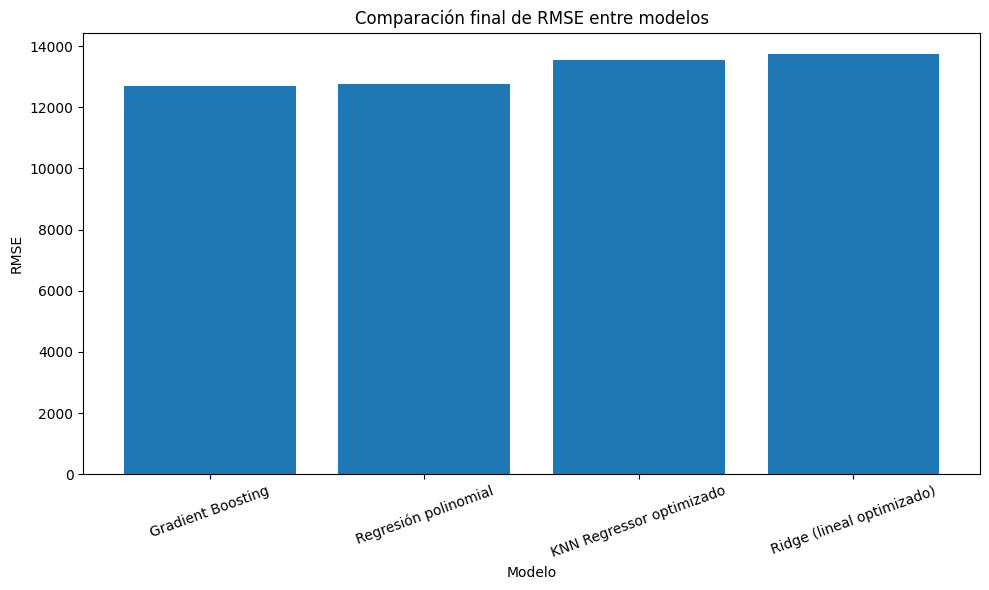


===== INTERPRETACIÓN FINAL =====
Mejores parámetros Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}

El mejor desempeño final lo obtuvo Gradient Boosting, con RMSE=12708.2660 y R²=0.7254.

Ventajas del boosting: captura relaciones no lineales, interacciones complejas y suele mejorar el desempeño predictivo.
Limitaciones del boosting: menor interpretabilidad que un modelo lineal, mayor costo computacional y mayor sensibilidad al ajuste de hiperparámetros.


In [12]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_DATASET_RAW = "../data/raw/clientes_ecommerce_ml_raw.csv"

df_boost = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# 1) LIMPIEZA DE TEXTO
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_ciudad = {
    "santiago": "Santiago",
    "valparaiso": "Valparaíso",
    "concepcion": "Concepción",
    "la serena": "La Serena",
    "antofagasta": "Antofagasta",
    "temuco": "Temuco",
    "rancagua": "Rancagua",
    "puerto montt": "Puerto Montt"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

mapa_dispositivo = {
    "mobile": "Mobile",
    "desktop": "Desktop",
    "tablet": "Tablet"
}

for col in ["sexo", "ciudad", "segmento_cliente", "canal_adquisicion", "cliente_premium", "usa_cupon", "dispositivo"]:
    df_boost[col] = df_boost[col].apply(normalizar_texto)

df_boost["sexo"] = df_boost["sexo"].replace({
    "mujer": "Mujer",
    "hombre": "Hombre",
    "otro": "Otro"
})

df_boost["ciudad"] = df_boost["ciudad"].map(mapa_ciudad)
df_boost["segmento_cliente"] = df_boost["segmento_cliente"].map(mapa_segmento)
df_boost["canal_adquisicion"] = df_boost["canal_adquisicion"].map(mapa_canal)
df_boost["cliente_premium"] = df_boost["cliente_premium"].replace({"si": "Sí", "no": "No"})
df_boost["usa_cupon"] = df_boost["usa_cupon"].replace({"si": "Sí", "no": "No"})
df_boost["dispositivo"] = df_boost["dispositivo"].map(mapa_dispositivo)

# =========================================================
# 2) INGENIERÍA DE CARACTERÍSTICAS
# =========================================================
df_boost["paginas_por_visita"] = df_boost["paginas_vistas"] / df_boost["visitas_sitio_mes"].replace(0, np.nan)
df_boost["tiempo_por_pagina"] = df_boost["tiempo_promedio_sitio_min"] / df_boost["paginas_vistas"].replace(0, np.nan)
df_boost["compras_por_visita"] = df_boost["compras_previas"] / df_boost["visitas_sitio_mes"].replace(0, np.nan)
df_boost["recencia_inversa"] = 1 / (df_boost["dias_desde_ultima_compra"] + 1)
df_boost["engagement_total"] = df_boost["visitas_sitio_mes"] + df_boost["paginas_vistas"]

# =========================================================
# 3) DEFINICIÓN DE X E y
# =========================================================
target = "monto_promedio_compra"

X = df_boost.drop(columns=["id_cliente", target]).copy()
y = df_boost[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# =========================================================
# 4) PREPROCESADORES
# =========================================================
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico_poly, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# =========================================================
# 5) MODELOS DE REFERENCIA
# =========================================================
# Ridge (lineal optimizado)
modelo_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])

# Polinomial
modelo_polinomial = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", LinearRegression())
])

# KNN optimizado
modelo_knn_opt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=7, p=2, weights="distance"))
])

modelo_ridge.fit(X_train, y_train)
modelo_polinomial.fit(X_train, y_train)
modelo_knn_opt.fit(X_train, y_train)

pred_ridge = modelo_ridge.predict(X_test)
pred_poly = modelo_polinomial.predict(X_test)
pred_knn = modelo_knn_opt.predict(X_test)

# =========================================================
# 6) PREPARACIÓN ESPECÍFICA PARA BOOSTING
# Gradient Boosting requiere matriz numérica densa
# =========================================================
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_test_pre = X_test_pre.toarray()

# =========================================================
# 7) GRADIENT BOOSTING CON GRIDSEARCHCV
# =========================================================
gbr = GradientBoostingRegressor(random_state=SEED)

param_grid_gbr = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_gbr.fit(X_train_pre, y_train)
pred_gbr = grid_gbr.predict(X_test_pre)

# =========================================================
# 8) MÉTRICAS
# =========================================================
def metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

mae_ridge, mse_ridge, rmse_ridge, r2_ridge = metricas(y_test, pred_ridge)
mae_poly, mse_poly, rmse_poly, r2_poly = metricas(y_test, pred_poly)
mae_knn, mse_knn, rmse_knn, r2_knn = metricas(y_test, pred_knn)
mae_gbr, mse_gbr, rmse_gbr, r2_gbr = metricas(y_test, pred_gbr)

tabla_final_modelos = pd.DataFrame([
    ["Ridge (lineal optimizado)", mae_ridge, mse_ridge, rmse_ridge, r2_ridge],
    ["Regresión polinomial", mae_poly, mse_poly, rmse_poly, r2_poly],
    ["KNN Regressor optimizado", mae_knn, mse_knn, rmse_knn, r2_knn],
    ["Gradient Boosting", mae_gbr, mse_gbr, rmse_gbr, r2_gbr]
], columns=["modelo", "MAE", "MSE", "RMSE", "R2"])

tabla_final_modelos = tabla_final_modelos.sort_values("RMSE").reset_index(drop=True)

print("===== COMPARACIÓN FINAL DE MODELOS =====")
display(tabla_final_modelos.round(4))

# =========================================================
# 9) IMPORTANCIA DE VARIABLES DEL BOOSTING
# =========================================================
feature_names_num = columnas_numericas
feature_names_cat = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(columnas_categoricas)
feature_names = list(feature_names_num) + list(feature_names_cat)

importancias = pd.DataFrame({
    "feature": feature_names,
    "importancia": grid_gbr.best_estimator_.feature_importances_
})

top_importancias = importancias.sort_values("importancia", ascending=False).head(15)

print("\n===== TOP 15 IMPORTANCIAS DEL GRADIENT BOOSTING =====")
display(top_importancias.round(4))

# =========================================================
# 10) VISUALIZACIÓN SIMPLE DE RMSE
# =========================================================
plt.figure(figsize=(10, 6))
plt.bar(tabla_final_modelos["modelo"], tabla_final_modelos["RMSE"])
plt.title("Comparación final de RMSE entre modelos")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# 11) INTERPRETACIÓN FINAL
# =========================================================
print("\n===== INTERPRETACIÓN FINAL =====")
print(f"Mejores parámetros Gradient Boosting: {grid_gbr.best_params_}")

mejor_modelo = tabla_final_modelos.iloc[0]

print(
    f"\nEl mejor desempeño final lo obtuvo {mejor_modelo['modelo']}, con "
    f"RMSE={mejor_modelo['RMSE']:.4f} y R²={mejor_modelo['R2']:.4f}."
)

print(
    "\nVentajas del boosting: captura relaciones no lineales, interacciones complejas y suele mejorar el desempeño predictivo."
)
print(
    "Limitaciones del boosting: menor interpretabilidad que un modelo lineal, mayor costo computacional y mayor sensibilidad al ajuste de hiperparámetros."
)

### Hallazgos de la Lección 8

En esta etapa se entrenó un modelo `GradientBoostingRegressor` y se comparó su desempeño frente a los principales modelos desarrollados en etapas anteriores. Esta comparación permitió evaluar si un enfoque ensemble mejora la capacidad predictiva respecto de modelos lineales optimizados y enfoques no lineales alternativos.

Además, se analizaron las variables más influyentes dentro del modelo de boosting, lo que permite complementar la evaluación predictiva con una lectura más útil para la toma de decisiones. Finalmente, la comparación global de métricas permitió seleccionar el modelo final del proyecto con base en su desempeño y robustez.